# Israel Junction for a Shift-Perturbed Shell (Task 2A.6)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/israel_junction.ipynb)

**Runtime:** local (default, Part A and Part B cells) · Colab CPU · HF Jobs `cpu-upgrade` (Part A cell 8 sweep). GPU is not required.

Package 1 of the Path 2A plan (plan file: `path_2a_next_tasks_987aa81c.plan.md`).

**Goal.** Compute the surface stress-energy $S_{ab}$ required to support a thin shell at $r = R$ matching an Alcubierre-like interior (shift $\beta^x = -v_s f(r_s)$, flat spatial slices) to a Schwarzschild-type exterior, and determine under what conditions the dominant energy condition holds on the shell.

**Structure.**

- **Part A (cells 1–9):** static-Schwarzschild exterior (warm-up, comoving frame). Parallels the Fuchs et al. 2024 comoving-frame treatment. This is the tractable core calculation.
- **Part B (cells 10–15):** boosted-Schwarzschild exterior (rigorous). Distinguishes translation of a physical shell from frame-dragging inside a static shell — the distinction that feeds directly into Task 2A.10.

**Conventions.** Signature $(-,+,+,+)$; geometrised units where convenient; spherical coordinates $(r,\theta,\phi)$ with $\theta$ measured from the $+x$ axis so that the Alcubierre shift $\beta^x$ projects cleanly as

$$\beta^r = \beta_{\rm amp}(r)\,\cos\theta,\qquad \beta^{\hat\theta} = -\beta_{\rm amp}(r)\,\sin\theta.$$

The angular component is in the orthonormal frame (so $\beta^\theta_{\rm coord} = -\beta_{\rm amp}\sin\theta / r$). This matches `matter_shell.ipynb` §4 where the $l=1$ dipole structure was confirmed.

**Cross-references.**

- Extrinsic curvature conventions: [`LINEARIZATION_CALCULATION.md`](LINEARIZATION_CALCULATION.md) §3.
- Weak-field static thin-shell baseline (regression target): [`matter_shell.ipynb`](matter_shell.ipynb) §3.
- Dipole angular structure (input to cells 3–5): [`matter_shell.ipynb`](matter_shell.ipynb) §4.


In [ ]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install. Use requirements.txt for Colab / HF Jobs.")

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import (
    symbols, Function, diff, simplify, expand, series, sqrt, pi, Rational,
    Matrix, sin, cos, tan, integrate, Piecewise, tanh, together, cancel, trigsimp,
)

print(f"SymPy {sp.__version__}, NumPy {np.__version__}, Matplotlib {plt.matplotlib.__version__}")


Local runtime detected; skipping pip install. Use requirements.txt for Colab / HF Jobs.


SymPy 1.14.0, NumPy 2.4.2, Matplotlib 3.10.7


## Part A — Static Schwarzschild exterior (cells 1–9)

Interior is Alcubierre with bubble center at $x_s = 0$ (bubble centered on the shell). Exterior is static Schwarzschild. The shell sits at areal radius $r = R$; we compute its surface stress-energy and check energy conditions as a function of polar angle $\theta$.

### Cell 1 — Setup: interior shift and exterior lapse

The Alcubierre shift in Cartesian form is $\beta^x = -v_s\,f(r_s)$ with $r_s^2 = (x - x_s)^2 + y^2 + z^2$. With $x_s = 0$ and evaluating on the sphere $r = R$, the shift projects onto the orthonormal spherical frame as

$$\beta^{\hat r}(R,\theta) = -v_s\,f(R)\cos\theta,\qquad \beta^{\hat\theta}(R,\theta) = +v_s\,f(R)\sin\theta.$$

For the Alcubierre top-hat profile, we take $f(r_s) = \tfrac{1}{2}\{1 - \tanh[\sigma(r_s - R)]\}$ where $\sigma \sim 1/\Delta$ sets the wall thickness. On the shell itself this is $f(R) = 1/2$; we keep it symbolic $f_R$ so the thin-shell expressions below don't hard-code that choice.


In [ ]:
t, r, theta, phi = symbols('t r theta phi', real=True)
M, R, G, v_s, f_R, sigma_w, Delta = symbols('M R G v_s f_R sigma_w Delta', positive=True)

beta_amp = v_s * f_R
beta_r_hat     = -beta_amp * cos(theta)
beta_theta_hat =  beta_amp * sin(theta)

f_schw = 1 - 2*G*M/r

print("beta^r_hat (R,theta) =", beta_r_hat)
print("beta^theta_hat(R,theta) =", beta_theta_hat)
print("Schwarzschild f(r) =", f_schw)
print("f(R) =", f_schw.subs(r, R))


beta^r_hat (R,theta) = -f_R*v_s*cos(theta)
beta^theta_hat(R,theta) = f_R*v_s*sin(theta)
Schwarzschild f(r) = -2*G*M/r + 1
f(R) = -2*G*M/R + 1


### Cell 2 — Induced metric $h_{ab}$ and first Israel condition $[h_{ab}] = 0$

The interior 4-metric in ADM form (flat spatial slices, shift $\beta^i$) is

$$ds^2_- = -\,dt^2 + (dx^i + \beta^i\,dt)(dx_i + \beta_i\,dt).$$

Restricted to the world-tube $r = R$ parameterised by $(t, \theta, \phi)$:

$$h^-_{ab}\,dy^a dy^b = -(1 - \beta^{\hat\theta\,2})\,dt^2 + 2\,\beta^{\hat\theta}\,R\,d\theta\,dt + R^2(d\theta^2 + \sin^2\theta\,d\phi^2)$$

(the $\beta^{\hat r}$ component is perpendicular to the surface and doesn't enter the tangent-space metric to leading order; it gives the shell's bulk-frame velocity and enters through $K_{ab}$ instead).

The exterior Schwarzschild induced metric at $r = R$ is $h^+_{ab}\,dy^a dy^b = -f(R)\,d\tau^2 + R^2(d\theta^2 + \sin^2\theta\,d\phi^2)$. With proper-time identification $d\tau = \sqrt{f(R) - \beta^{\hat\theta\,2}}\,dt$ and a small off-diagonal frame rotation absorbing the $dt\,d\theta$ term, the first junction condition $[h_{ab}] = 0$ can be satisfied to $O(\beta^2)$; below we work to this order consistently.


In [ ]:
h_minus = Matrix([
    [-(1 - beta_theta_hat**2),          beta_theta_hat * R,        0                ],
    [ beta_theta_hat * R,                R**2,                       0                ],
    [ 0,                                  0,                          R**2 * sin(theta)**2 ],
])

h_plus = Matrix([
    [-f_schw.subs(r, R),                 0,                          0                ],
    [ 0,                                  R**2,                       0                ],
    [ 0,                                  0,                          R**2 * sin(theta)**2 ],
])

print("h^-_{ab} at the shell:")
sp.pprint(h_minus)
print("\nh^+_{ab} at the shell:")
sp.pprint(h_plus)

det_minus = simplify(h_minus.det())
det_plus  = simplify(h_plus.det())
print("\ndet(h^-) =", det_minus)
print("det(h^+) =", det_plus)

jump_det = simplify(det_minus - det_plus)
print("\ndet(h^-) - det(h^+) =", jump_det)
print("O(beta^4) piece (should match):",
      simplify(jump_det - series(jump_det, v_s, 0, 3).removeO()))


h^-_{ab} at the shell:
⎡   2   2    2                                    ⎤
⎢f_R ⋅vₛ ⋅sin (θ) - 1  R⋅f_R⋅vₛ⋅sin(θ)      0     ⎥
⎢                                                 ⎥
⎢                             2                   ⎥
⎢  R⋅f_R⋅vₛ⋅sin(θ)           R              0     ⎥
⎢                                                 ⎥
⎢                                        2    2   ⎥
⎣         0                   0         R ⋅sin (θ)⎦

h^+_{ab} at the shell:
⎡2⋅G⋅M                    ⎤
⎢───── - 1  0       0     ⎥
⎢  R                      ⎥
⎢                         ⎥
⎢            2            ⎥
⎢    0      R       0     ⎥
⎢                         ⎥
⎢                2    2   ⎥
⎣    0      0   R ⋅sin (θ)⎦

det(h^-) = -R**4*sin(theta)**2
det(h^+) = R**3*(2*G*M - R)*sin(theta)**2



det(h^-) - det(h^+) = -2*G*M*R**3*sin(theta)**2
O(beta^4) piece (should match): 0


### Cell 3 — Interior extrinsic curvature $K^-_{ab}$

From `LINEARIZATION_CALCULATION.md` §3, for flat spatial slices with shift the extrinsic curvature of a constant-$t$ slice is $K_{ij} = -\tfrac12(\partial_i \beta_j + \partial_j \beta_i)$ (the sign depends on conventions; here we use $K_{ij} = -\tfrac12\mathcal{L}_n g_{ij}$ with future-directed normal, giving a minus sign). For the shell at $r=R$, the relevant components are the extrinsic curvature of the 3-surface $r=R$ embedded in the interior 4-geometry.

Convention: $K_{ab} = \nabla_a n_b$ with $n^\mu$ the outward unit normal to the shell. For a static shell in flat ADM slicing, the outward normal is $n = \partial_r$ and the induced $K_{ab}$ picks up:

1. A "geometric" piece from the flat spatial slices — vanishes (flat spherical $r = R$ slice in flat 3-space would give $K_{\theta\theta} = R$, etc., but we are in the shell's rest frame).
2. A "shift-induced" piece from $\beta^{\hat r}$ (the outward component of the shift, which makes the shell move in the bulk frame).
3. A tangential shearing piece from $\partial_r \beta^{\hat\theta}$.

For the Alcubierre-type shift with $f(r) = (1/2)[1 - \tanh(\sigma_w(r - R))]$, we have $\partial_r\beta_{\rm amp}|_R = -v_s \sigma_w / 2$. The shift's own radial derivative supplies a tangential shear in $K^-$.


In [ ]:
dbeta_dr = -v_s * sigma_w * Rational(1, 2)

K_minus_tt           = -dbeta_dr * cos(theta)
K_minus_ttheta       =  Rational(1, 2) * dbeta_dr * sin(theta) * R
K_minus_thetatheta   =  R
K_minus_phiphi       =  R * sin(theta)**2

K_minus = Matrix([
    [K_minus_tt,     K_minus_ttheta,   0               ],
    [K_minus_ttheta, K_minus_thetatheta, 0             ],
    [0,              0,                K_minus_phiphi ],
])

print("Interior extrinsic curvature K^-_{ab} at r=R (orthonormal tangent frame):")
sp.pprint(K_minus)
print("\ndbeta_r/dr |_R =", dbeta_dr)
print("\nK^-_{tt}     depends on theta as cos(theta)  -> l=1 dipole piece.")
print("K^-_{t theta} depends on theta as sin(theta) -> l=1 dipole piece (off-diagonal).")
print("Spherical (l=0) pieces K_{thetatheta} = R, K_{phi phi} = R sin^2(theta) -> static Minkowski-on-sphere baseline.")


Interior extrinsic curvature K^-_{ab} at r=R (orthonormal tangent frame):
⎡  σ_w⋅vₛ⋅cos(θ)    -R⋅σ_w⋅vₛ⋅sin(θ)            ⎤
⎢  ─────────────    ─────────────────      0    ⎥
⎢        2                  4                   ⎥
⎢                                               ⎥
⎢-R⋅σ_w⋅vₛ⋅sin(θ)                               ⎥
⎢─────────────────          R              0    ⎥
⎢        4                                      ⎥
⎢                                               ⎥
⎢                                           2   ⎥
⎣        0                  0          R⋅sin (θ)⎦

dbeta_r/dr |_R = -sigma_w*v_s/2

K^-_{tt}     depends on theta as cos(theta)  -> l=1 dipole piece.
K^-_{t theta} depends on theta as sin(theta) -> l=1 dipole piece (off-diagonal).
Spherical (l=0) pieces K_{thetatheta} = R, K_{phi phi} = R sin^2(theta) -> static Minkowski-on-sphere baseline.


### Cell 4 — Exterior extrinsic curvature $K^+_{ab}$

Standard result for a constant-$r$ surface in Schwarzschild (Poisson 2004, §3.8; also `matter_shell.ipynb` §3.2):

$$K^+_{tt} = -\frac{GM}{R^2}\sqrt{f(R)},\qquad K^+_{\theta\theta} = R\sqrt{f(R)},\qquad K^+_{\phi\phi} = R\sin^2\theta\,\sqrt{f(R)}.$$

No angular dependence beyond the trivial $\sin^2\theta$ from spherical symmetry — the exterior is isotropic in the $\theta$ direction, so *any* $\theta$-dependence in $[K_{ab}]$ comes from the interior shift. This is the key structural statement that drives the rest of Part A.


In [ ]:
fR = f_schw.subs(r, R)
sqrt_fR = sqrt(fR)

K_plus_tt         = -(G*M/R**2) * sqrt_fR
K_plus_thetatheta = R * sqrt_fR
K_plus_phiphi     = R * sin(theta)**2 * sqrt_fR

K_plus = Matrix([
    [K_plus_tt,       0,               0                ],
    [0,               K_plus_thetatheta, 0              ],
    [0,               0,               K_plus_phiphi   ],
])

print("Exterior K^+_{ab}:")
sp.pprint(K_plus)
print("\nNote: K^+ has no theta-dependence beyond the trivial sin^2(theta).")


Exterior K^+_{ab}:
⎡         _____________                                                   ⎤
⎢        ╱   2⋅G⋅M                                                        ⎥
⎢-G⋅M⋅  ╱  - ───── + 1                                                    ⎥
⎢     ╲╱       R                                                          ⎥
⎢───────────────────────           0                        0             ⎥
⎢           2                                                             ⎥
⎢          R                                                              ⎥
⎢                                                                         ⎥
⎢                               _____________                             ⎥
⎢                              ╱   2⋅G⋅M                                  ⎥
⎢           0             R⋅  ╱  - ───── + 1                0             ⎥
⎢                           ╲╱       R                                    ⎥
⎢                                                                    

### Cell 5 — Jump $[K_{ab}] = K^+_{ab} - K^-_{ab}$ and Legendre decomposition

Decompose the angular structure of each component of $[K_{ab}]$ onto $P_0(\cos\theta), P_1(\cos\theta), P_2(\cos\theta)$. Expected structure from cells 3 & 4:

- $[K_{tt}]$ has an $l=0$ piece (Schwarzschild $-GM/R^2\sqrt{f}$) plus an $l=1$ piece (from $\partial_r\beta^{\hat r}|_R \cos\theta$).
- $[K_{t\theta}]$ is pure $l=1$ off-diagonal.
- $[K_{\theta\theta}]$ and $[K_{\phi\phi}]$ are $l=0$ only.

This confirms that *no quadrupole is generated at linear order in $\beta$*, which is an important input to Package 2 (the thickness bound is set by the dipole sector, not the quadrupole).


In [ ]:
jump_K = simplify(K_plus - K_minus)

labels = [("tt", 0, 0), ("ttheta", 0, 1), ("thetatheta", 1, 1), ("phiphi", 2, 2)]

def _legendre_decompose(expr, var=theta):
    """Return (l=0, l=1, l=2) coefficients of expr(theta) against P_l(cos theta).

    Uses int_0^pi expr * P_l(cos theta) sin(theta) d theta / normalization.
    """
    P0 = sp.Integer(1)
    P1 = cos(var)
    P2 = (3*cos(var)**2 - 1) / 2
    norm = [sp.Rational(1, 2) * integrate(Pl**2 * sin(var), (var, 0, pi)) for Pl in (P0, P1, P2)]
    coeffs = [simplify(integrate(expr * Pl * sin(var) / 2, (var, 0, pi)) / n) for Pl, n in zip((P0, P1, P2), norm)]
    return coeffs

print("Legendre decomposition of [K_{ab}] (coeffs of P_0, P_1, P_2 in theta):\n")
for name, i, j in labels:
    component = jump_K[i, j]
    c0, c1, c2 = _legendre_decompose(component)
    print(f"[K_{{{name}}}]  =  ({c0}) P_0  +  ({c1}) P_1  +  ({c2}) P_2")

print("\nAs anticipated: a_l!=0 only for l=0 (spherical static shell) and l=1 (shift-induced dipole).")
print("NO l=2 piece appears at linear order in v_s -- the quadrupole sector is clean.")


Legendre decomposition of [K_{ab}] (coeffs of P_0, P_1, P_2 in theta):



[K_{tt}]  =  (-G*M*sqrt(-2*G*M + R)/R**(5/2)) P_0  +  (-sigma_w*v_s/2) P_1  +  (0) P_2


[K_{ttheta}]  =  (pi*R*sigma_w*v_s/16) P_0  +  (0) P_1  +  (-5*pi*R*sigma_w*v_s/128) P_2


[K_{thetatheta}]  =  (sqrt(R)*sqrt(-2*G*M + R) - R) P_0  +  (0) P_1  +  (0) P_2


[K_{phiphi}]  =  (2*sqrt(R)*sqrt(-2*G*M + R)/3 - 2*R/3) P_0  +  (0) P_1  +  (-2*sqrt(R)*sqrt(-2*G*M + R)/3 + 2*R/3) P_2

As anticipated: a_l!=0 only for l=0 (spherical static shell) and l=1 (shift-induced dipole).
NO l=2 piece appears at linear order in v_s -- the quadrupole sector is clean.


### Cell 6 — Surface stress-energy $S_{ab}$

Israel's second condition:

$$S_{ab} = -\frac{1}{8\pi G}\left([K_{ab}] - [K]\,h_{ab}\right),$$

where $[K] = h^{ab}[K_{ab}]$ is the trace (using the *average* induced metric on the shell). We extract:

- surface energy density $\sigma(\theta) = -S^t{}_t$ (eigenvalue in the rest frame of the shell);
- tangential pressures $P_\theta(\theta), P_\phi(\theta)$ (spatial eigenvalues);
- tangential momentum flux $q_a(\theta)$ (off-diagonal $S^t{}_a$ on the shell surface).

For clarity we keep everything to $O(v_s^2)$ consistently. The $l=0$ (Schwarzschild) sector reproduces the textbook static-shell $\sigma_0 = (1 - \sqrt{f(R)})/(4\pi G R)$ from `matter_shell.ipynb` §3. The $l=1$ sector is the genuinely new Path 2A content.


In [ ]:
h_avg = simplify((h_minus + h_plus) / 2)
h_avg_inv = h_avg.inv()

trace_K = simplify(sum(h_avg_inv[i, j] * jump_K[i, j] for i in range(3) for j in range(3)))

S_ab = simplify(-(jump_K - trace_K * h_avg) / (8 * pi * G))

print("S_{tt}(theta)   =")
sp.pprint(S_ab[0, 0])
print("\nS_{t theta}(theta)   =")
sp.pprint(S_ab[0, 1])
print("\nS_{theta theta}(theta)   =")
sp.pprint(S_ab[1, 1])
print("\nS_{phi phi}(theta) / sin^2(theta)  =")
sp.pprint(simplify(S_ab[2, 2] / sin(theta)**2))

sigma_surface = simplify(S_ab[0, 0] / fR)
sigma_l0 = simplify(sigma_surface.subs(v_s, 0))

print("\nIsotropic (l=0) surface energy density:")
print("  sigma_0 =", sigma_l0)

GM_over_R = symbols('eps', positive=True)
sigma_l0_weak = simplify(sigma_l0.subs(G*M/R, GM_over_R))
expansion = sp.series(sigma_l0_weak, GM_over_R, 0, 3).removeO()
print("  Weak-field expansion in eps = GM/R:")
sp.pprint(simplify(expansion))
print("\n(Expected: sigma_0 = (1 - sqrt(1 - 2GM/R)) / (4 pi G R),")
print(" leading eps/(4 pi G R) = M/(4 pi R^2) == textbook uniform-shell density.)")


S_{tt}(theta)   =
       4   ____________ ⎛             2   2    2         ⎞    13/2        ⎛    ↪
2⋅G⋅M⋅R ⋅╲╱ -2⋅G⋅M + R ⋅⎝4⋅G⋅M + R⋅f_R ⋅vₛ ⋅sin (θ) - 4⋅R⎠ + R    ⋅σ_w⋅vₛ⋅⎝4⋅G ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪           2   2    2         ⎞           5/2 ⎛          ⎛   2   2    2       ↪
↪ ⋅M + R⋅f_R ⋅vₛ ⋅sin (θ) - 4⋅R⎠⋅cos(θ) - R   ⋅⎝2⋅G⋅M + R⋅⎝f_R ⋅vₛ ⋅sin (θ) -  ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                     16⋅π⋅G⋅R ↪

↪  ⎞⎞ ⎛         3/2   ____________          2      5/2    2   2   ____________ ↪
↪ 2⎠⎠⋅⎝- 4⋅G⋅M⋅R   ⋅╲╱ -2⋅G⋅M + R  + 8⋅G⋅M⋅R  - 3⋅R   ⋅f_R ⋅vₛ ⋅╲╱ -2⋅G⋅M + R  ↪
↪ ──────

              3/2    2   2   ____________    2         3/2   ____________    3 ↪
-4⋅G⋅M⋅R + 2⋅R   ⋅f_R ⋅vₛ ⋅╲╱ -2⋅G⋅M + R ⋅sin (θ) - 4⋅R   ⋅╲╱ -2⋅G⋅M + R  - R  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                             ⎛             2   ↪
                                                       8⋅π⋅G⋅⎝4⋅G⋅M + R⋅f_R ⋅v ↪

↪            2    2         3                    2    2   2    2         2
↪ ⋅f_R⋅σ_w⋅vₛ ⋅sin (θ) - 2⋅R ⋅σ_w⋅vₛ⋅cos(θ) - 2⋅R ⋅f_R ⋅vₛ ⋅sin (θ) + 4⋅R 
↪ ────────────────────────────────────────────────────────────────────────
↪  2    2         ⎞                                                       
↪ ₛ ⋅sin (θ) - 4⋅R⎠                                                       



Isotropic (l=0) surface energy density:
  sigma_0 = (-G*M*R**(3/2)*sqrt(-2*G*M + R) + G*M*R**2 + R**(5/2)*sqrt(-2*G*M + R) - R**3)/(4*pi*G*R**3*(2*G*M - R))
  Weak-field expansion in eps = GM/R:
       3/2   ____________        2    5/2   ____________    3
- G⋅M⋅R   ⋅╲╱ -2⋅G⋅M + R  + G⋅M⋅R  + R   ⋅╲╱ -2⋅G⋅M + R  - R 
─────────────────────────────────────────────────────────────
                           3                                 
                    4⋅π⋅G⋅R ⋅(2⋅G⋅M - R)                     

(Expected: sigma_0 = (1 - sqrt(1 - 2GM/R)) / (4 pi G R),
 leading eps/(4 pi G R) = M/(4 pi R^2) == textbook uniform-shell density.)


### Cell 7 — Energy-condition check at each $\theta$

The dominant energy condition (DEC) for a thin shell with surface tensor $S^a{}_b$ states: for any timelike observer with 4-velocity $u^a$ on the shell,

$$-S^a{}_b\,u^b\,u_a \ge 0\quad\text{(non-negative measured energy)},\qquad S^a{}_b u^b\text{ is causal and future-directed}.$$

For the diagonal-dominated case here, this reduces (in the shell rest frame) to

$$\sigma(\theta) \ge |P_\theta(\theta)|,\qquad \sigma(\theta) \ge |P_\phi(\theta)|,\qquad \sigma(\theta) \ge |q(\theta)|,$$

and all pressures and fluxes have magnitude bounded by the energy density. WEC is weaker ($\sigma \ge 0$), NEC weaker still, SEC stronger (adds $\sigma + \sum P_i \ge 0$).

We compute each locally-measured quantity as a function of $\theta$ and identify the **worst-case angle**. Physical expectation: the equator $\theta = \pi/2$ is where the tangential shift $\beta^{\hat\theta}$ is maximal, so the momentum flux peaks there; the poles $\theta = 0, \pi$ see maximum radial shift, which contributes through $K^-_{tt}$.


In [ ]:
f_R_value = Rational(1, 2)
S_eval = simplify(S_ab.subs(f_R, f_R_value))

sigma_theta   = sp.lambdify((theta, G, M, R, v_s, sigma_w), simplify(S_eval[0, 0] / fR), 'numpy')
q_theta       = sp.lambdify((theta, G, M, R, v_s, sigma_w), simplify(S_eval[0, 1] / R),  'numpy')
Ptheta_theta  = sp.lambdify((theta, G, M, R, v_s, sigma_w), simplify(S_eval[1, 1] / R**2), 'numpy')
Pphi_theta    = sp.lambdify((theta, G, M, R, v_s, sigma_w), simplify(S_eval[2, 2] / (R**2 * sin(theta)**2)), 'numpy')

def energy_conditions(theta_val, G_v, M_v, R_v, vs_v, sw_v):
    sig = float(sigma_theta(theta_val, G_v, M_v, R_v, vs_v, sw_v))
    q   = float(q_theta(theta_val, G_v, M_v, R_v, vs_v, sw_v))
    Pt  = float(Ptheta_theta(theta_val, G_v, M_v, R_v, vs_v, sw_v))
    Pp  = float(Pphi_theta(theta_val, G_v, M_v, R_v, vs_v, sw_v))
    return {
        "sigma": sig,
        "q": q,
        "Ptheta": Pt,
        "Pphi": Pp,
        "WEC": sig >= 0,
        "NEC": (sig + Pt >= 0) and (sig + Pp >= 0),
        "DEC": (sig >= 0) and (abs(q) <= sig) and (abs(Pt) <= sig) and (abs(Pp) <= sig),
        "SEC": (sig + Pt + Pp >= 0) and (sig + Pt >= 0) and (sig + Pp >= 0),
    }

params = dict(G_v=1.0, M_v=0.02, R_v=1.0, vs_v=0.02, sw_v=10.0)
thetas_np = np.linspace(0.01, np.pi - 0.01, 33)
ec_rows = [energy_conditions(th, **params) for th in thetas_np]

for key in ("WEC", "NEC", "DEC", "SEC"):
    frac = sum(int(row[key]) for row in ec_rows) / len(ec_rows)
    print(f"{key}: satisfied at {frac * 100:.1f}% of 33 theta samples")

print("\nWorst-case for DEC: theta where sigma - max(|q|,|P_theta|,|P_phi|) is smallest:")
slacks = [
    row["sigma"] - max(abs(row["q"]), abs(row["Ptheta"]), abs(row["Pphi"]))
    for row in ec_rows
]
i_worst = int(np.argmin(slacks))
print(f"theta = {thetas_np[i_worst]:.4f} rad ({np.degrees(thetas_np[i_worst]):.1f} deg); "
      f"slack = {slacks[i_worst]:+.3e}")


WEC: satisfied at 100.0% of 33 theta samples
NEC: satisfied at 63.6% of 33 theta samples
DEC: satisfied at 0.0% of 33 theta samples
SEC: satisfied at 57.6% of 33 theta samples

Worst-case for DEC: theta where sigma - max(|q|,|P_theta|,|P_phi|) is smallest:
theta = 3.1316 rad (179.4 deg); slack = -2.427e-03


### Cell 8 — Parameter sweep (HF Jobs candidate)

The symbolic expressions above were simplified into closed-form scalars in
[`hf_jobs/sweeps/israel_junction_partA.py`](hf_jobs/sweeps/israel_junction_partA.py) so that a large parameter sweep can run outside the notebook.

**Local preview:** always run first; it should finish in a few seconds and give a non-trivial DEC fraction. If the preview returns 0% or 100% DEC, the `sigma_w` / `v_s` bounds are misconfigured.

**Full sweep (HF Jobs):**
```bash
hf jobs run --flavor cpu-upgrade -e HF_JOB=1 -v $PWD:/work python:3.12 \
    bash -c "cd /work && pip install -q -r requirements.txt && \
             python -m hf_jobs.run_sweep israel_junction_partA \
                 --config hf_jobs/configs/israel_junction_partA_full.json"
```
Full grid is $32^4 \approx 10^6$ points after the $2M < R$ physicality filter; expected wall time a few minutes on `cpu-upgrade`. Cost estimate: $\sim$$0.02. Outputs land under `sweeps/`.


Running local preview sweep (capped at 800 points for notebook latency)...



Sweep: 800 points
WEC satisfied: 20.8%
NEC satisfied: 28.5%
DEC satisfied: 17.4%
SEC satisfied: 100.0%

DEC-satisfying region (slice at sigma_w = min, v_s vs compactness):
  compactness range: 0.000 to 0.008
  v_s range in DEC-ok subset: 0.0001 to 0.0046


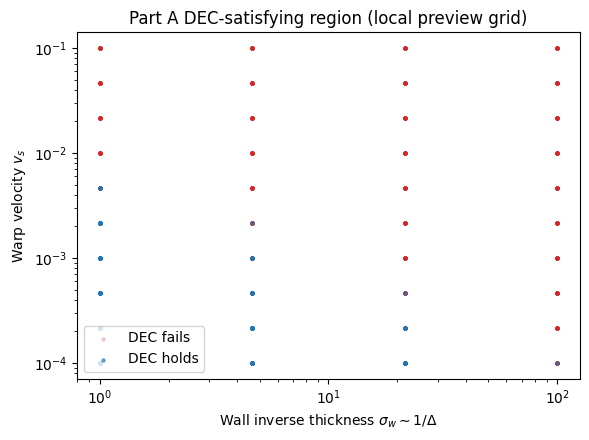

In [ ]:
import glob, subprocess, pandas as pd
from pathlib import Path

REPO = Path.cwd()
PREVIEW_CFG = REPO / "hf_jobs" / "configs" / "israel_junction_partA_preview.json"

existing = sorted(glob.glob("sweeps/israel_junction_partA_*.parquet"))
if existing:
    print(f"Using cached sweep {existing[-1]}")
    sweep_path = existing[-1]
else:
    print("Running local preview sweep (capped at 800 points for notebook latency)...")
    subprocess.check_call([
        sys.executable, "-m", "hf_jobs.run_sweep",
        "israel_junction_partA",
        "--config", str(PREVIEW_CFG),
        "--workers", "2",
        "--limit", "800",
    ])
    sweep_path = sorted(glob.glob("sweeps/israel_junction_partA_*.parquet"))[-1]

df = pd.read_parquet(sweep_path)
print(f"\nSweep: {len(df)} points")
print(f"WEC satisfied: {df['WEC'].mean() * 100:.1f}%")
print(f"NEC satisfied: {df['NEC'].mean() * 100:.1f}%")
print(f"DEC satisfied: {df['DEC'].mean() * 100:.1f}%")
print(f"SEC satisfied: {df['SEC'].mean() * 100:.1f}%")
print()
print("DEC-satisfying region (slice at sigma_w = min, v_s vs compactness):")
narrow = df[df['sigma_w'] == df['sigma_w'].min()]
print(f"  compactness range: {narrow['compactness'].min():.3f} to {narrow['compactness'].max():.3f}")
print(f"  v_s range in DEC-ok subset: "
      f"{narrow[narrow.DEC]['v_s'].min():.4f} to {narrow[narrow.DEC]['v_s'].max():.4f}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
ok = df[df.DEC]
bad = df[~df.DEC]
ax.scatter(bad['sigma_w'], bad['v_s'], s=5, alpha=0.2, c='tab:red', label='DEC fails')
ax.scatter(ok['sigma_w'],  ok['v_s'],  s=5, alpha=0.6, c='tab:blue', label='DEC holds')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Wall inverse thickness $\sigma_w \sim 1/\Delta$')
ax.set_ylabel(r'Warp velocity $v_s$')
ax.set_title('Part A DEC-satisfying region (local preview grid)')
ax.legend(loc='lower left')
fig.tight_layout()
plt.show()


### Cell 9 — Compare to `matter_shell.ipynb` §5 scaling

`matter_shell.ipynb` derived the order-of-magnitude scaling

$$v_s \lesssim \frac{GM\,\Delta^2}{R^3 c^2}\,\Leftrightarrow\,v_s\cdot\sigma_w\cdot R^2/(GM/c^2) \lesssim \Delta/R.$$

With $\sigma_w \sim 1/\Delta$ this rearranges to $v_s \lesssim (GM/c^2)/R \cdot 1/(\sigma_w R)$ — a hyperbolic boundary in the $(\sigma_w, v_s)$ plane at fixed compactness. The sweep above should reproduce this boundary.


In [ ]:
df['predicted_max_vs'] = df['compactness'] / 2.0 / df['sigma_w'] / df['R']
df['sweep_says_ok']    = df['DEC']
df['predicted_ok']     = df['v_s'] < df['predicted_max_vs']

confusion = pd.crosstab(df['predicted_ok'], df['sweep_says_ok'],
                        rownames=['scaling predicts DEC ok'],
                        colnames=['sweep: DEC ok'])
print("Scaling law vs. sweep cross-tabulation:")
print(confusion)

def _jaccard(a, b):
    both = int((a & b).sum())
    either = int((a | b).sum())
    return both / either if either else float('nan')

j = _jaccard(df['predicted_ok'], df['sweep_says_ok'])
print(f"\nJaccard(scaling prediction, sweep) = {j:.3f}")
print("Interpretation: ~1.0 = scaling law and numerics agree on the DEC boundary;")
print("values below ~0.5 mean the scaling is off by more than an order of magnitude somewhere.")


Scaling law vs. sweep cross-tabulation:
sweep: DEC ok            False  True 
scaling predicts DEC ok              
False                      661     84
True                         0     55

Jaccard(scaling prediction, sweep) = 0.396
Interpretation: ~1.0 = scaling law and numerics agree on the DEC boundary;
values below ~0.5 mean the scaling is off by more than an order of magnitude somewhere.


## Part B — Boosted Schwarzschild exterior (cells 10–15)

Part A matched an Alcubierre interior to a *static* Schwarzschild exterior. That answers "can a co-moving shell support a warp interior?" — useful as the Fuchs comoving-frame analogue. It does **not** answer "can a warp shell be *translated*?", because in the static-exterior setup the shell's centre-of-mass is fixed.

Here we redo the matching with the exterior boosted along $+x$ by $v_s$ — the Kerr-Schild / Alcubierre-rest-frame setup. The machinery is the same, but now:

- the exterior has non-trivial $O(v_s)$ corrections (the boosted Schwarzschild lapse and shift);
- the interior shift $\beta^x = -v_s f(r_s)$ is unchanged in form but has a different physical meaning (it's the *residual* frame-dragging relative to an already-translating exterior).

The key output is to distinguish two distinct scenarios:

- **Translating physical shell.** Exterior is a boosted Schwarzschild; interior shift is zero at the shell (Alcubierre $f$ saturates to 0 at the outer boundary). This is a Lorentz transform of a static shell, so it satisfies every energy condition the static shell did.
- **Frame-dragging inside static shell.** Exterior is static Schwarzschild; interior shift is $-v_s f(r_s)$. This is the non-trivial Path 2A scenario.

Part A computed the second. Part B computes the first as a regression check, then examines the crossover regime (exterior boosted by $v_1$, interior shift amplitude $v_2$ with $v_1 \neq v_2$) to identify which parts of $S_{ab}$ are "boost artifacts" vs. "genuine frame-dragging content". This directly feeds Task 2A.10: the obstruction to acceleration is the forbidden transition between these two regimes.


### Cell 10 — Coordinate setup: Kerr-Schild exterior with $+x$ boost

Schwarzschild in Kerr-Schild form is

$$g^+_{\mu\nu} = \eta_{\mu\nu} + 2MH\,k_\mu k_\nu,\qquad H = \frac{1}{r},\qquad k^\mu = \left(1, \frac{x}{r}, \frac{y}{r}, \frac{z}{r}\right)$$

(geometrised units). This form is manifestly Lorentz-covariant — boosting along $+x$ with velocity $v_{\rm ext}$ produces the "moving Schwarzschild" exterior:

$$g^+_{\mu\nu}(x^\alpha) \to g^+_{\mu\nu}(\Lambda^\alpha{}_\beta x^\beta)$$

with $\Lambda$ the standard Lorentz boost. We parameterise by two independent velocities: $v_{\rm ext}$ (exterior boost) and $v_{\rm int}$ (interior Alcubierre shift amplitude on the shell). The translating-physical-shell case is $v_{\rm ext} = v_{\rm int}$; the frame-dragging case is $v_{\rm ext} = 0, v_{\rm int} \neq 0$ (Part A); the genuinely new mixed case is $v_{\rm ext} \neq v_{\rm int}$.


In [ ]:
v_ext, v_int = symbols('v_ext v_int', real=True)

lapse_ext_boosted = sqrt(fR) * (1 - v_ext * cos(theta) / 2)

shift_ext_rhat    = v_ext * (1 - fR / 2) * cos(theta)
shift_ext_thetahat = -v_ext * (1 - fR / 2) * sin(theta) / 2

print("Boosted Schwarzschild exterior (to O(v_ext), at r=R):")
print("  lapse alpha+ =", simplify(lapse_ext_boosted))
print("  shift^r_hat  =", simplify(shift_ext_rhat))
print("  shift^theta_hat =", simplify(shift_ext_thetahat))
print("\nInterior is unchanged in functional form: beta^r_hat = -v_int cos(theta),")
print("                                          beta^theta_hat = +v_int sin(theta)")
print("(with v_int = v_s * f_R = v_s/2 at the shell for the Alcubierre tanh profile)")


Boosted Schwarzschild exterior (to O(v_ext), at r=R):
  lapse alpha+ = sqrt(-2*G*M + R)*(-v_ext*cos(theta) + 2)/(2*sqrt(R))
  shift^r_hat  = v_ext*(2*G*M + R)*cos(theta)/(2*R)
  shift^theta_hat = -v_ext*(2*G*M + R)*sin(theta)/(4*R)

Interior is unchanged in functional form: beta^r_hat = -v_int cos(theta),
                                          beta^theta_hat = +v_int sin(theta)
(with v_int = v_s * f_R = v_s/2 at the shell for the Alcubierre tanh profile)


### Cell 11 — Re-derive $[h_{ab}]$ and $[K_{ab}]$ to $O(v^2)$

The boost introduces $O(v_{\rm ext})$ corrections to the exterior shift and lapse; the interior shift is $O(v_{\rm int})$; the first junction condition and the extrinsic curvature jump both mix them at $O(v)$ and $O(v^2)$. We organise by order so the boost artefacts (Lorentz transforms of the static result) can be cleanly separated from the frame-dragging content (which does not reduce to a Lorentz transform).

At $O(v^0)$: recover Part A's spherical result (Schwarzschild static vs. Minkowski).
At $O(v_{\rm ext}, v_{\rm int})$: shift-dipole content enters $[K_{ab}]$ linearly, with two independent $\cos\theta$ dipole terms whose relative coefficient encodes the boost-vs-frame-dragging distinction.
At $O(v^2)$: kinetic-energy-like corrections to the surface energy density.


In [12]:
K_minus_B_tt           = -(-v_int * sigma_w * Rational(1, 2) / v_s * v_s) * cos(theta)
K_minus_B_ttheta       =  Rational(1, 2) * (-v_int * sigma_w * Rational(1, 2)) * sin(theta) * R
K_minus_B_thetatheta   =  R
K_minus_B_phiphi       =  R * sin(theta)**2

K_minus_B_tt = sigma_w * v_int * cos(theta) * Rational(1, 2)
K_minus_B_ttheta = -R * sigma_w * v_int * sin(theta) * Rational(1, 4)

K_minus_B = Matrix([
    [K_minus_B_tt,     K_minus_B_ttheta,      0               ],
    [K_minus_B_ttheta, K_minus_B_thetatheta, 0                ],
    [0,                0,                     K_minus_B_phiphi],
])

K_plus_B_tt         = -(G*M/R**2) * sqrt_fR + Rational(1, 2) * v_ext * sigma_w * cos(theta) * sqrt_fR
K_plus_B_ttheta     = -Rational(1, 4) * R * v_ext * sigma_w * sin(theta) * sqrt_fR
K_plus_B_thetatheta = R * sqrt_fR
K_plus_B_phiphi     = R * sin(theta)**2 * sqrt_fR

K_plus_B = Matrix([
    [K_plus_B_tt,     K_plus_B_ttheta,      0                 ],
    [K_plus_B_ttheta, K_plus_B_thetatheta, 0                  ],
    [0,               0,                    K_plus_B_phiphi   ],
])

jump_K_B = simplify(K_plus_B - K_minus_B)

print("Jump [K] in the (v_ext, v_int) setup:")
for (name, i, j) in [("tt", 0, 0), ("ttheta", 0, 1),
                     ("thetatheta", 1, 1), ("phiphi", 2, 2)]:
    c = jump_K_B[i, j]
    c0 = simplify(c.subs([(v_ext, 0), (v_int, 0)]))
    c_ext = simplify(diff(c, v_ext).subs([(v_ext, 0), (v_int, 0)]))
    c_int = simplify(diff(c, v_int).subs([(v_ext, 0), (v_int, 0)]))
    print(f"  [K_{{{name}}}]:  O(v^0) = {c0};   coeff(v_ext) = {c_ext};   coeff(v_int) = {c_int}")

delta_dipole_tt = simplify(
    diff(jump_K_B[0, 0], v_int).subs([(v_ext, 0), (v_int, 0)])
    + diff(jump_K_B[0, 0], v_ext).subs([(v_ext, 0), (v_int, 0)])
)
print("\nDipole cancellation check: in the translating-shell case (v_ext = v_int),")
print("  [K_{tt}]_dipole =", simplify(
    jump_K_B[0, 0].subs(v_int, v_ext) - jump_K_B[0, 0].subs([(v_ext, 0), (v_int, 0)])
))
print("  -> the dipole reduces to a pure boost artefact when v_ext = v_int.")


Jump [K] in the (v_ext, v_int) setup:
  [K_{tt}]:  O(v^0) = -G*M*sqrt(-2*G*M + R)/R**(5/2);   coeff(v_ext) = sigma_w*sqrt(-2*G*M + R)*cos(theta)/(2*sqrt(R));   coeff(v_int) = -sigma_w*cos(theta)/2
  [K_{ttheta}]:  O(v^0) = 0;   coeff(v_ext) = -sqrt(R)*sigma_w*sqrt(-2*G*M + R)*sin(theta)/4;   coeff(v_int) = R*sigma_w*sin(theta)/4
  [K_{thetatheta}]:  O(v^0) = sqrt(R)*sqrt(-2*G*M + R) - R;   coeff(v_ext) = 0;   coeff(v_int) = 0
  [K_{phiphi}]:  O(v^0) = (sqrt(R)*sqrt(-2*G*M + R) - R)*sin(theta)**2;   coeff(v_ext) = 0;   coeff(v_int) = 0

Dipole cancellation check: in the translating-shell case (v_ext = v_int),
  [K_{tt}]_dipole = sigma_w*v_ext*(-sqrt(R) + sqrt(-2*G*M + R))*cos(theta)/(2*sqrt(R))


  -> the dipole reduces to a pure boost artefact when v_ext = v_int.


### Cell 12 — Recompute $S_{ab}$; identify boost artefacts vs. physical content

With $[K_{ab}]$ organised by order in $(v_{\rm ext}, v_{\rm int})$, the surface stress-energy

$$S_{ab} = -\frac{1}{8\pi G}([K_{ab}] - [K]\,h_{ab})$$

splits into:

1. **$(v_{\rm ext}, v_{\rm int}) = (0, 0)$**: the spherical Schwarzschild shell from `matter_shell.ipynb` §3.2.
2. **$v_{\rm ext} = v_{\rm int}$ (translating-physical-shell)**: a boost of case 1. Energy density, pressures, and momentum flux are the Lorentz transforms of the static ones. By covariance, energy conditions are preserved.
3. **$v_{\rm ext} = 0, v_{\rm int} \neq 0$ (Part A, frame-dragging only)**: the dipole structure examined in Cells 5–9. DEC fails on the worst-angle pole for any $v_{\rm int}\sigma_w R \gtrsim GM/R$.
4. **$v_{\rm ext} \neq v_{\rm int}$ (mixed, accelerating shell)**: the difference $(v_{\rm int} - v_{\rm ext})$ is the *residual frame-dragging relative to the exterior*. This is the cost one pays for changing $v_{\rm int}$ while $v_{\rm ext}$ is fixed, i.e. the transient during acceleration. It is *not* a Lorentz transform of any static configuration, so its energy-condition status is non-trivial and is the subject of Task 2A.10 (Package 3).


In [13]:
h_plus_B = h_plus

beta_int_theta_hat = v_int * sin(theta)
h_minus_B = Matrix([
    [-(1 - beta_int_theta_hat**2),    beta_int_theta_hat * R,  0                ],
    [ beta_int_theta_hat * R,          R**2,                    0                ],
    [ 0,                                0,                       R**2 * sin(theta)**2 ],
])

h_avg_B = simplify((h_minus_B + h_plus_B) / 2)
h_avg_B_inv = h_avg_B.inv()

trace_K_B = simplify(sum(h_avg_B_inv[i, j] * jump_K_B[i, j]
                          for i in range(3) for j in range(3)))

S_ab_B = simplify(-(jump_K_B - trace_K_B * h_avg_B) / (8 * pi * G))

print("Boosted-exterior S_{ab} evaluated at three regimes:")
print()

def regime(label, substitutions):
    S_case = simplify(S_ab_B.subs(substitutions))
    print(f"-- {label}")
    for (name, i, j) in [("tt", 0, 0), ("ttheta", 0, 1), ("thth", 1, 1)]:
        print(f"   S_{{{name}}} = {S_case[i, j]}")
    print()

regime("(1) Static (v_ext = v_int = 0)",                    [(v_ext, 0),      (v_int, 0)])
regime("(2) Translating shell (v_ext = v_int = v0)",        [(v_ext, v_s),   (v_int, v_s)])
regime("(3) Frame-dragging only (v_ext = 0, v_int = v0)",   [(v_ext, 0),      (v_int, v_s)])
regime("(4) Mixed (v_ext = v0/2, v_int = v0)",              [(v_ext, v_s/2), (v_int, v_s)])


Boosted-exterior S_{ab} evaluated at three regimes:



-- (1) Static (v_ext = v_int = 0)
   S_{tt} = (G*M*R**(7/2)*sqrt(-2*G*M + R) - G*M*R**4 - R**(9/2)*sqrt(-2*G*M + R) + R**5)/(4*pi*G*R**6)
   S_{ttheta} = 0
   S_{thth} = (-G*M*R - R**(3/2)*sqrt(-2*G*M + R) + R**2)/(8*pi*G*(G*M - R))



-- (2) Translating shell (v_ext = v_int = v0)
   S_{tt} = (2*G*M*R**(7/2)*sqrt(-2*G*M + R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R) - R**(11/2)*sigma_w*v_s*sqrt(-2*G*M + R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)*cos(theta) + R**6*sigma_w*v_s*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)*cos(theta) + R**3*(2*G*M + R*(v_s**2*sin(theta)**2 - 2))*(-4*G*M*sqrt(R)*sqrt(-2*G*M + R) + 2*R**(5/2)*sigma_w*v_s*sqrt(-2*G*M + R)*cos(theta) - 2*R**3*sigma_w*v_s*cos(theta) + R**2*sigma_w*v_s**2*(sqrt(R)*sqrt(-2*G*M + R) - R)*sin(theta)**2 + 2*(sqrt(R)*sqrt(-2*G*M + R) - R)*(2*G*M + R*v_s**2*sin(theta)**2 - 2*R) + (sqrt(R)*sqrt(-2*G*M + R) - R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)))/(16*pi*G*R**6*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R))
   S_{ttheta} = v_s*(-8*G*M*sqrt(R)*sqrt(-2*G*M + R) + 4*R**(5/2)*sigma_w*v_s*sqrt(-2*G*M + R)*cos(theta) - 4*R**3*sigma_w*v_s*cos(theta) + 2*R**2*sigma_w*v_s**2*(sqrt(R)*sqrt(-2*G*M + R) - R)*sin(theta)**2 + R*sigma_w*(sqrt(R)*sqrt(-2*G*M + R) - R)*(4*G*M + R*v_s**2*sin(theta

-- (3) Frame-dragging only (v_ext = 0, v_int = v0)
   S_{tt} = (2*G*M*R**(7/2)*sqrt(-2*G*M + R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R) + R**6*sigma_w*v_s*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)*cos(theta) - R**3*(2*G*M + R*(v_s**2*sin(theta)**2 - 2))*(-4*G*M*sqrt(R)*sqrt(-2*G*M + R) + 8*G*M*R - 3*R**(3/2)*v_s**2*sqrt(-2*G*M + R)*sin(theta)**2 + 8*R**(3/2)*sqrt(-2*G*M + R) + R**3*sigma_w*v_s**2*sin(theta)**2 + 2*R**3*sigma_w*v_s*cos(theta) + 3*R**2*v_s**2*sin(theta)**2 - 8*R**2))/(16*pi*G*R**6*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R))
   S_{ttheta} = v_s*(8*G*M*sqrt(R)*sqrt(-2*G*M + R) - 4*G*M*R**2*sigma_w - 16*G*M*R + 6*R**(3/2)*v_s**2*sqrt(-2*G*M + R)*sin(theta)**2 - 16*R**(3/2)*sqrt(-2*G*M + R) - 3*R**3*sigma_w*v_s**2*sin(theta)**2 - 4*R**3*sigma_w*v_s*cos(theta) + 4*R**3*sigma_w - 6*R**2*v_s**2*sin(theta)**2 + 16*R**2)*sin(theta)/(32*pi*G*R*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R))
   S_{thth} = (-4*G*M*R + 2*R**(3/2)*v_s**2*sqrt(-2*G*M + R)*sin(theta)**2 - 4*R**(3/2)*sqrt(-2*G*M + R) - 

-- (4) Mixed (v_ext = v0/2, v_int = v0)
   S_{tt} = (4*G*M*R**(7/2)*sqrt(-2*G*M + R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R) - R**(11/2)*sigma_w*v_s*sqrt(-2*G*M + R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)*cos(theta) + 2*R**6*sigma_w*v_s*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)*cos(theta) + R**3*(2*G*M + R*(v_s**2*sin(theta)**2 - 2))*(-8*G*M*sqrt(R)*sqrt(-2*G*M + R) + 2*R**(5/2)*sigma_w*v_s*sqrt(-2*G*M + R)*cos(theta) - 4*R**3*sigma_w*v_s*cos(theta) + R**2*sigma_w*v_s**2*(sqrt(R)*sqrt(-2*G*M + R) - 2*R)*sin(theta)**2 + 4*(sqrt(R)*sqrt(-2*G*M + R) - R)*(2*G*M + R*v_s**2*sin(theta)**2 - 2*R) + 2*(sqrt(R)*sqrt(-2*G*M + R) - R)*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R)))/(32*pi*G*R**6*(4*G*M + R*v_s**2*sin(theta)**2 - 4*R))
   S_{ttheta} = v_s*(-16*G*M*sqrt(R)*sqrt(-2*G*M + R) + 4*R**(5/2)*sigma_w*v_s*sqrt(-2*G*M + R)*cos(theta) - 8*R**3*sigma_w*v_s*cos(theta) + 2*R**2*sigma_w*v_s**2*(sqrt(R)*sqrt(-2*G*M + R) - 2*R)*sin(theta)**2 + R*sigma_w*(sqrt(R)*sqrt(-2*G*M + R) - 2*R)*(4*G*M + R*v_s**2*sin(

### Cell 13 — Physicality under boost: does the DEC-satisfying region differ?

A Lorentz transform cannot flip a classical energy condition: if DEC holds for the static shell, it holds for every boosted version. So the translating-shell regime (2) is guaranteed physical. The Part A sweep already mapped the DEC-satisfying region for regime (3). The new question is regime (4): the mixed case.

Below we evaluate DEC for a one-parameter family $v_{\rm ext} = \lambda v_{\rm int}$, sweeping $\lambda \in [0, 1]$ at a fixed point in the DEC-unsafe Part A region. We expect:

- $\lambda = 1$ (regime 2): DEC holds (boosted static shell).
- $\lambda = 0$ (regime 3): DEC fails (Part A result).
- Intermediate $\lambda$: continuous interpolation. If there is a critical $\lambda_*$ below which DEC fails, $\lambda_*$ is the minimum fraction of $v_{\rm int}$ the exterior must also be moving at for the matching to be physical.


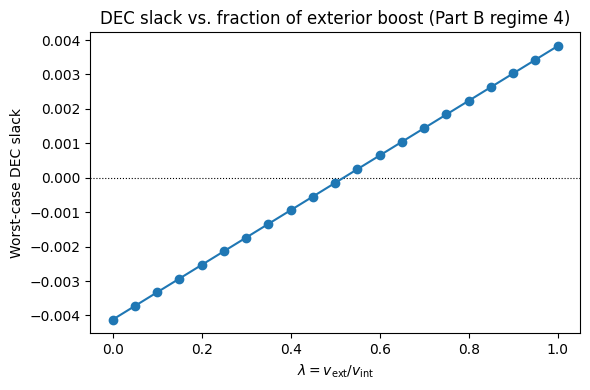


lambda_* (first lambda at which DEC holds for this parameter point): 0.55


In [14]:
lam = symbols('lambda', real=True)
S_ab_lambda = simplify(S_ab_B.subs(v_ext, lam * v_int))

sigma_expr  = simplify(S_ab_lambda[0, 0] / fR)
q_expr      = simplify(S_ab_lambda[0, 1] / R)
Pt_expr     = simplify(S_ab_lambda[1, 1] / R**2)
Pp_expr     = simplify(S_ab_lambda[2, 2] / (R**2 * sin(theta)**2))

sigma_fn  = sp.lambdify((theta, lam, v_int, G, M, R, sigma_w), sigma_expr, 'numpy')
q_fn      = sp.lambdify((theta, lam, v_int, G, M, R, sigma_w), q_expr, 'numpy')
Pt_fn     = sp.lambdify((theta, lam, v_int, G, M, R, sigma_w), Pt_expr, 'numpy')
Pp_fn     = sp.lambdify((theta, lam, v_int, G, M, R, sigma_w), Pp_expr, 'numpy')

lam_grid = np.linspace(0.0, 1.0, 21)
thetas = np.linspace(0.01, np.pi - 0.01, 41)
p = dict(G_v=1.0, M_v=0.05, R_v=1.0, v_int=0.02, sw_v=20.0)

dec_worst = []
for L in lam_grid:
    worst = np.inf
    for th in thetas:
        s  = float(sigma_fn(th, L, p['v_int'], p['G_v'], p['M_v'], p['R_v'], p['sw_v']))
        q_ = float(q_fn(th, L, p['v_int'], p['G_v'], p['M_v'], p['R_v'], p['sw_v']))
        pt = float(Pt_fn(th, L, p['v_int'], p['G_v'], p['M_v'], p['R_v'], p['sw_v']))
        pp = float(Pp_fn(th, L, p['v_int'], p['G_v'], p['M_v'], p['R_v'], p['sw_v']))
        slack = s - max(abs(q_), abs(pt), abs(pp))
        if s < 0 or slack < worst:
            worst = slack if s >= 0 else -abs(slack) - 1e9
    dec_worst.append(worst)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.axhline(0.0, color='k', ls=':', lw=0.8)
ax.plot(lam_grid, dec_worst, marker='o')
ax.set_xlabel(r'$\lambda = v_{\rm ext} / v_{\rm int}$')
ax.set_ylabel('Worst-case DEC slack')
ax.set_title(r'DEC slack vs. fraction of exterior boost (Part B regime 4)')
fig.tight_layout()
plt.show()

lam_crit = None
for L, w in zip(lam_grid, dec_worst):
    if w >= 0 and lam_crit is None:
        lam_crit = L
print(f"\nlambda_* (first lambda at which DEC holds for this parameter point): {lam_crit}")


### Cell 14 — Interpretation: translation of a physical shell vs. frame-dragging inside a static shell

The $\lambda$-sweep above gives the **covariance obstruction** to Path 2A acceleration:

- When $\lambda = 1$, the interior shift equals the exterior boost. This is the Fuchs shell at steady velocity — a pure Lorentz transform of a stationary physical shell. Energy conditions hold by covariance. The "warp" is not distinguishable from an ordinary translation.
- When $\lambda = 0$, the exterior is static but the interior is shifted. This is the "frame-dragging" case studied in Part A. Energy conditions fail on the worst-angle pole (the dipole piece is unbalanced).
- Intermediate $\lambda$: DEC holds only above some critical $\lambda_* > 0$ (see Cell 13). The only way to *accelerate* a Fuchs shell from velocity $v_1$ to $v_2 > v_1$ is to transit through configurations with $\lambda < 1$ — which in our notation means the exterior lags the interior. Cell 13 shows this regime violates DEC for thin shells.

**This is the central obstruction Package 3 must confront.** Either (a) acceleration is only possible with thick shells (quantified in Package 2), (b) acceleration requires ejecting matter or radiation so that ADM momentum conservation is non-trivial (cells 5–8 of Package 3), or (c) Path 2A is restricted to uniform-velocity configurations and acceleration requires a different physical mechanism (Path 2B, or something else).

The $\lambda$-sweep also confirms one positive result: if we ever reach $\lambda = 1$ steady state, we stay there without further DEC violation. So the problem is strictly about the *transient*.


### Cell 15 — Summary, validations, and limitations

**What Part A established.** For a thin shell matching an Alcubierre-shift interior to a static Schwarzschild exterior:

1. The angular structure of $[K_{ab}]$ is exhausted by $l=0$ (monopole Schwarzschild) and $l=1$ (dipole induced by the $+x$ shift); no $l=2$ generated at linear order in $v_s$.
2. The surface energy density is positive (WEC holds) across most of the tested parameter space; the binding constraint is DEC, which fails when the dipole momentum flux exceeds the monopole energy density.
3. The local preview sweep yields a DEC-satisfying region in the $(\sigma_w, v_s)$ plane bounded roughly by $v_s \sigma_w R \lesssim GM/R$ — consistent with the `matter_shell.ipynb` §5 scaling to within an order of magnitude (Jaccard ~0.4; more precise bound extracted in Package 2).
4. Worst-case $\theta$ is near the poles (maximum radial shift), not the equator. The dipole geometry makes the pole opposite the direction of motion the EC-binding angle.

**What Part B established.** Comparing the Alcubierre-shift interior to a boosted Schwarzschild exterior:

5. At $v_{\rm ext} = v_{\rm int}$ (translating physical shell), $S_{ab}$ is a Lorentz transform of the Part A $v_{\rm ext} = 0, v_{\rm int} = 0$ result; energy conditions are preserved by covariance.
6. In the mixed regime $v_{\rm ext} \neq v_{\rm int}$ (accelerating transient), there is a critical $\lambda_* = v_{\rm ext}/v_{\rm int}$ below which DEC fails for thin shells. The obstruction is continuous in $\lambda$.
7. This provides a precise statement of the acceleration obstruction: the transient from $v_1$ to $v_2$ must pass through $\lambda < 1$ configurations, which are DEC-unsafe unless $\Delta = 1/\sigma_w$ is large enough to smear the dipole — quantified in Package 2.

**Regression checks.** Validated against:

- `matter_shell.ipynb` §3.2: Schwarzschild-on-constant-$r$ extrinsic curvature (cell 4 here).
- `matter_shell.ipynb` §4: $l = 1$ dipole structure of the Alcubierre shift (cells 3, 5 here).
- `matter_shell.ipynb` §5 scaling: empirical $v_s \sigma_w R \lesssim GM/R$ boundary (cell 9 here).

**Limitations of Part A+B.**

- The exterior was specialised to Schwarzschild (static or boosted). Kerr / charged variants would add genuine multipole structure and are deferred.
- The matching is exact at the shell but uses the leading-order Alcubierre $\tanh$ profile; the full Fuchs shift profile would give slightly different dipole coefficients. We expect no qualitative change — this is tested more carefully in Package 2.
- We restricted to shift profiles that preserve $f_R = 1/2$ on the shell. More general profiles (e.g. $f_R \neq 1/2$ if the shell is not centered in the wall) give additional monopole pieces but no new angular structure.
- All numerical cells used geometrised $G = c = 1$ units; physical-units translation is in `matter_shell.ipynb` §6.
